# Student Academic Performance Analysis

This project explores how academic behavior, lifestyle, and socioeconomic
factors influence student performance.

Research Questions:
- Does study time affect grades?
- Do previous grades academic performance?
- Do students with internet access perform better?
- Does social lifestyle affect exam scores?

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

In [3]:
df=pd.read_csv("data//student-mat.csv", sep=";")
df

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,4,6,10,10
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
390,MS,M,20,U,LE3,A,2,2,services,services,...,5,5,4,4,5,4,11,9,9,9
391,MS,M,17,U,LE3,T,3,1,services,services,...,2,4,5,3,4,2,3,14,16,16
392,MS,M,21,R,GT3,T,1,1,other,other,...,5,5,3,3,3,3,3,10,8,7
393,MS,M,18,R,LE3,T,3,2,services,other,...,4,4,1,3,4,5,0,11,12,10


# Data Understanding

In [4]:
df.shape

(395, 33)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 395 entries, 0 to 394
Data columns (total 33 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   school      395 non-null    object
 1   sex         395 non-null    object
 2   age         395 non-null    int64 
 3   address     395 non-null    object
 4   famsize     395 non-null    object
 5   Pstatus     395 non-null    object
 6   Medu        395 non-null    int64 
 7   Fedu        395 non-null    int64 
 8   Mjob        395 non-null    object
 9   Fjob        395 non-null    object
 10  reason      395 non-null    object
 11  guardian    395 non-null    object
 12  traveltime  395 non-null    int64 
 13  studytime   395 non-null    int64 
 14  failures    395 non-null    int64 
 15  schoolsup   395 non-null    object
 16  famsup      395 non-null    object
 17  paid        395 non-null    object
 18  activities  395 non-null    object
 19  nursery     395 non-null    object
 20  higher    

In [6]:
df.describe()

,age,Medu,Fedu,traveltime,studytime,failures,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
count,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000
mean,16.696203,2.749367,2.521519,1.448101,2.035443,0.334177,3.944304,3.235443,3.108861,1.481013,2.291139,3.554430,5.708861,10.908861,10.713924,10.415190
std,1.276043,1.094735,1.088201,0.697505,0.839240,0.743651,0.896659,0.998862,1.113278,0.890741,1.287897,1.390303,8.003096,3.319195,3.761505,4.581443
min,15.000000,0.000000,0.000000,1.000000,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,3.000000,0.000000,0.000000
25%,16.000000,2.000000,2.000000,1.000000,1.000000,0.000000,4.000000,3.000000,2.000000,1.000000,1.000000,3.000000,0.000000,8.000000,9.000000,8.000000
50%,17.000000,3.000000,2.000000,1.000000,2.000000,0.000000,4.000000,3.000000,3.000000,1.000000,2.000000,4.000000,4.000000,11.000000,11.000000,11.000000
75%,18.000000,4.000000,3.000000,2.000000,2.000000,0.000000,5.000000,4.000000,4.000000,2.000000,3.000000,5.000000,8.000000,13.000000,13.000000,14.000000
max,22.000000,4.000000,4.000000,4.000000,4.000000,3.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,75.000000,19.000000,19.000000,20.000000


# Data Preparation and Cleaning
        

In [7]:
df.columns

Index(['school', 'sex', 'age', 'address', 'famsize', 'Pstatus', 'Medu', 'Fedu',
       'Mjob', 'Fjob', 'reason', 'guardian', 'traveltime', 'studytime',
       'failures', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery',
       'higher', 'internet', 'romantic', 'famrel', 'freetime', 'goout', 'Dalc',
       'Walc', 'health', 'absences', 'G1', 'G2', 'G3'],
      dtype='object')

In [8]:
df.rename(columns={
    "school": "School",
    "sex": "Gender",
    "age": "Age",
    "address": "Residence_Type",
    "famsize": "Family_Size",
    "Pstatus": "Parent_Cohabitation_Status",
    "Medu": "Mother_Education_Level",
    "Fedu": "Father_Education_Level",
    "Mjob": "Mother_Job",
    "Fjob": "Father_Job",
    "reason": "School_Choice_Reason",
    "guardian": "Guardian",
    "traveltime": "Travel_Time_To_School",
    "studytime": "Weekly_Study_Time",
    "failures": "Past_Class_Failures",
    "schoolsup": "Extra_Educational_Support",
    "famsup": "Family_Educational_Support",
    "paid": "Extra_Paid_Classes",
    "activities": "Extracurricular_Activities",
    "nursery": "Attended_Nursery",
    "higher": "Wants_Higher_Education",
    "internet": "Internet_Access",
    "romantic": "Romantic_Relationship",
    "famrel": "Family_Relationship_Quality",
    "freetime": "Free_Time_After_School",
    "goout": "Going_Out_With_Friends",
    "Dalc": "Weekday_Alcohol_Consumption",
    "Walc": "Weekend_Alcohol_Consumption",
    "health": "Health_Status",
    "absences": "School_Absences",
    "G1": "First_Period_Grade",
    "G2": "Second_Period_Grade",
    "G3": "Final_Grade"
}, inplace=True)

In [9]:
df.columns

Index(['School', 'Gender', 'Age', 'Residence_Type', 'Family_Size',
       'Parent_Cohabitation_Status', 'Mother_Education_Level',
       'Father_Education_Level', 'Mother_Job', 'Father_Job',
       'School_Choice_Reason', 'Guardian', 'Travel_Time_To_School',
       'Weekly_Study_Time', 'Past_Class_Failures', 'Extra_Educational_Support',
       'Family_Educational_Support', 'Extra_Paid_Classes',
       'Extracurricular_Activities', 'Attended_Nursery',
       'Wants_Higher_Education', 'Internet_Access', 'Romantic_Relationship',
       'Family_Relationship_Quality', 'Free_Time_After_School',
       'Going_Out_With_Friends', 'Weekday_Alcohol_Consumption',
       'Weekend_Alcohol_Consumption', 'Health_Status', 'School_Absences',
       'First_Period_Grade', 'Second_Period_Grade', 'Final_Grade'],
      dtype='object')

In [85]:
df.isnull().sum()

School                         0
Gender                         0
Age                            0
Residence_Type                 0
Family_Size                    0
Parent_Cohabitation_Status     0
Mother_Education_Level         0
Father_Education_Level         0
Mother_Job                     0
Father_Job                     0
School_Choice_Reason           0
Guardian                       0
Travel_Time_To_School          0
Weekly_Study_Time              0
Past_Class_Failures            0
Extra_Educational_Support      0
Family_Educational_Support     0
Extra_Paid_Classes             0
Extracurricular_Activities     0
Attended_Nursery               0
Wants_Higher_Education         0
Internet_Access                0
Romantic_Relationship          0
Family_Relationship_Quality    0
Free_Time_After_School         0
Going_Out_With_Friends         0
Weekday_Alcohol_Consumption    0
Weekend_Alcohol_Consumption    0
Health_Status                  0
School_Absences                0
First_Peri

In [89]:
df.duplicated()

0      False
1      False
2      False
3      False
4      False
       ...  
390    False
391    False
392    False
393    False
394    False
Length: 395, dtype: bool

# Handling Anamolies

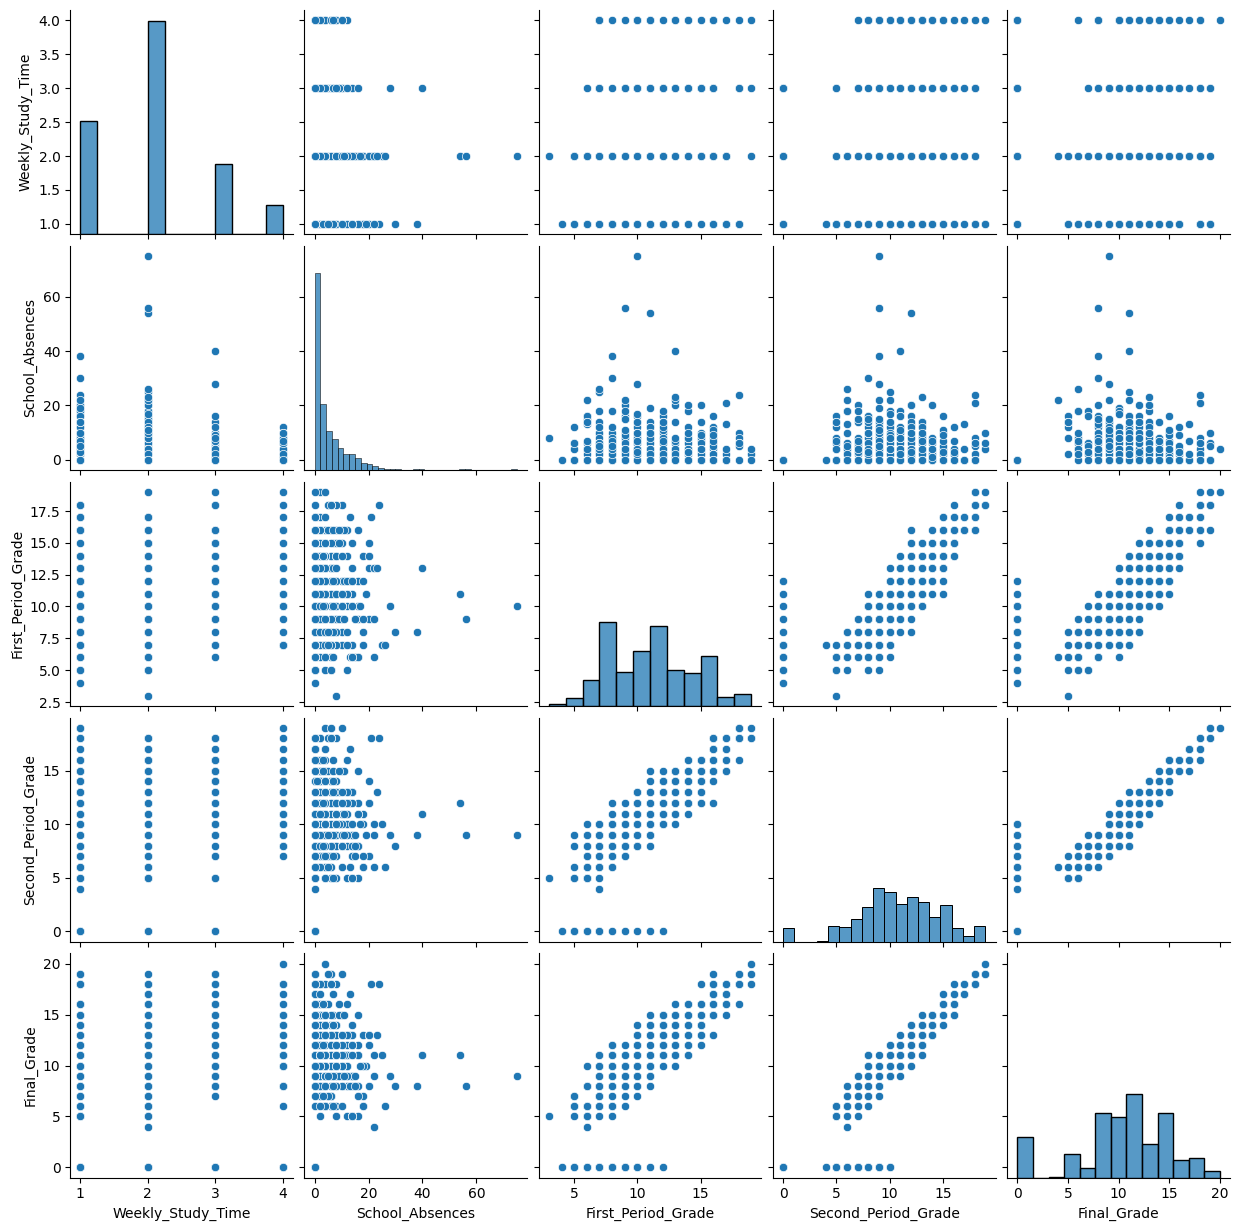

In [91]:
sns.pairplot(df[[
    "Weekly_Study_Time",
    "School_Absences",
    "First_Period_Grade",
    "Second_Period_Grade",
    "Final_Grade"
]])

## Potential Anamolies
### School_Absences

* Most values are between 0–20, but some go up to 60–75. These high values are likely outliers.

### Grades (First, Second, Final)

* Grades mostly range 5–18, but there are some 0 values despite 0 absences. If 0 means missing or unrealistic scores, they may be anomalies.

#### Weekly_Study_Time

* Values are discrete (1–4), so they are not really anomalies.



In [108]:
df = df[df['School_Absences'] < 40]
df = df[df['Final_Grade'] != 0]
df = df[df['First_Period_Grade'] != 0]
df = df[df['Second_Period_Grade'] != 0]

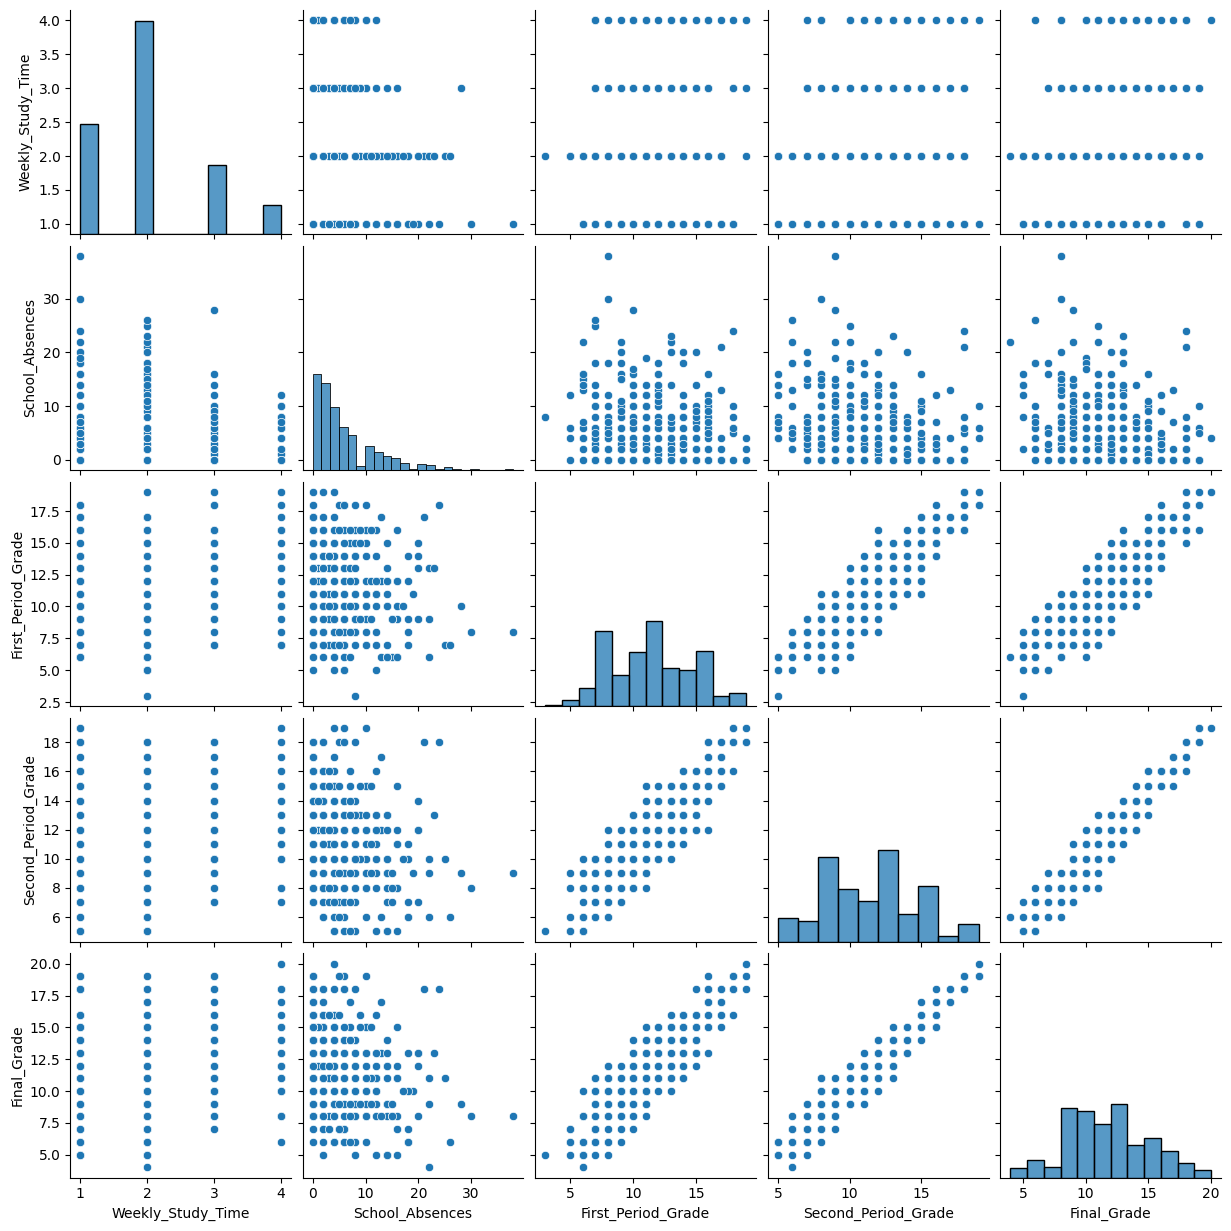

In [109]:
sns.pairplot(df[[
    "Weekly_Study_Time",
    "School_Absences",
    "First_Period_Grade",
    "Second_Period_Grade",
    "Final_Grade"
]])

# Exploratory Data Analysis

## Univariate Analysis

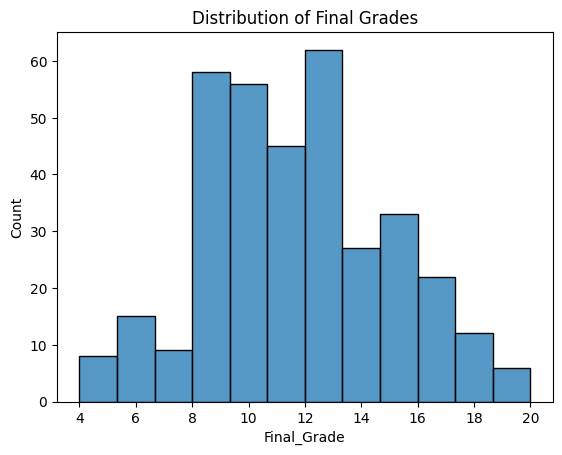

In [ ]:

sns.histplot(df["Final_Grade"],)
plt.title("Distribution of Final Grades")
plt.show()


Majority Students' grades are between 8 and 16

## Bivariate Analysis

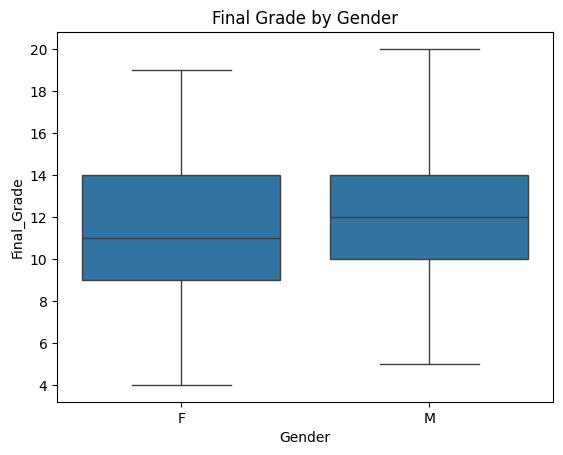

In [111]:
sns.boxplot(x="Gender", y="Final_Grade", data=df)
plt.title("Final Grade by Gender")
plt.show()

Males have slightly Higher Grades

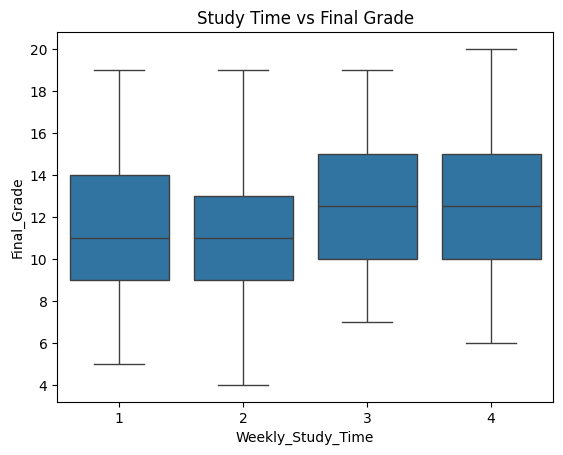

In [112]:
sns.boxplot(x="Weekly_Study_Time", y="Final_Grade", data=df)
plt.title("Study Time vs Final Grade")
plt.show()

More Study Time yields better results

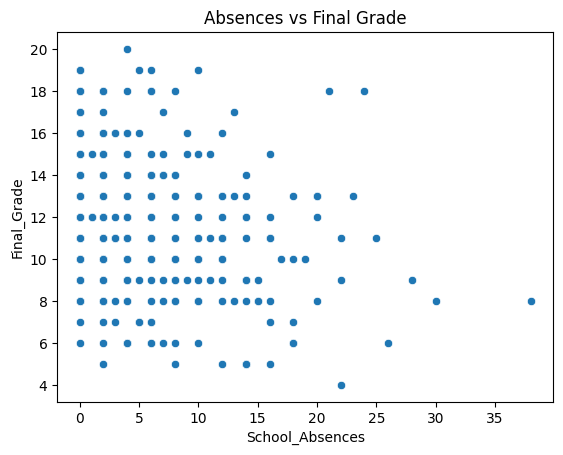

In [113]:
sns.scatterplot(x="School_Absences", y="Final_Grade", data=df)
plt.title("Absences vs Final Grade")
plt.show()

More Absences leads to worse grades

Text(0.5, 1.0, 'Weekend Alcohol Consumption vs Grades')

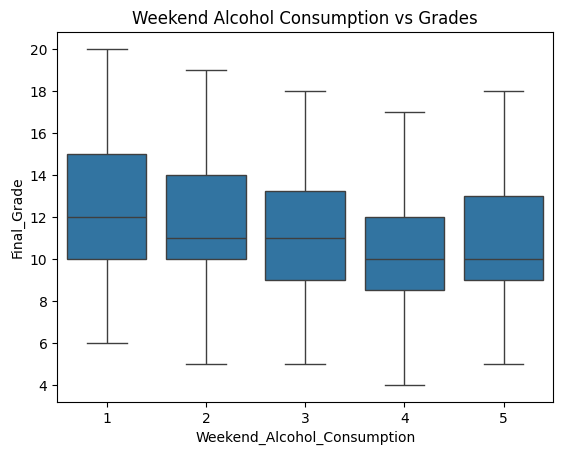

In [116]:
sns.boxplot(x="Weekend_Alcohol_Consumption", y="Final_Grade", data=df)
plt.title("Weekend Alcohol Consumption vs Grades")

Increased Alcohol Consumption Leads to worse final grades

Text(0.5, 1.0, 'Social Activity vs Academic Performance')

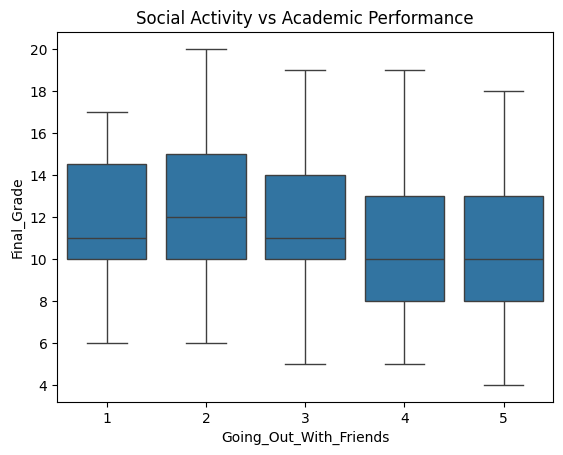

In [117]:
sns.boxplot(x="Going_Out_With_Friends", y="Final_Grade", data=df)
plt.title("Social Activity vs Academic Performance")

<Axes: xlabel='Internet_Access', ylabel='Final_Grade'>

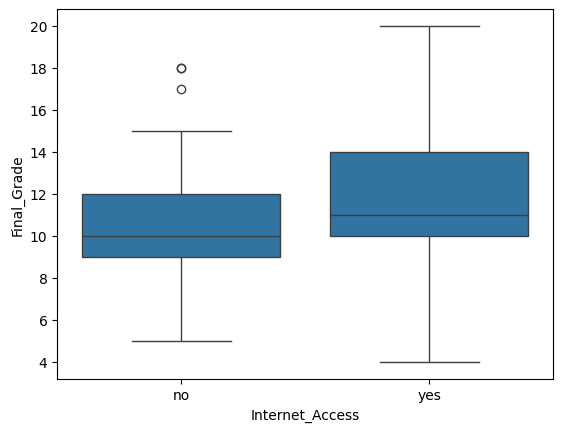

In [120]:
sns.boxplot(x="Internet_Access", y="Final_Grade", data=df)

Internet Availability Improves Student Performance

## Correlation Analysis

Text(0.5, 1.0, 'Correlation Matrix')

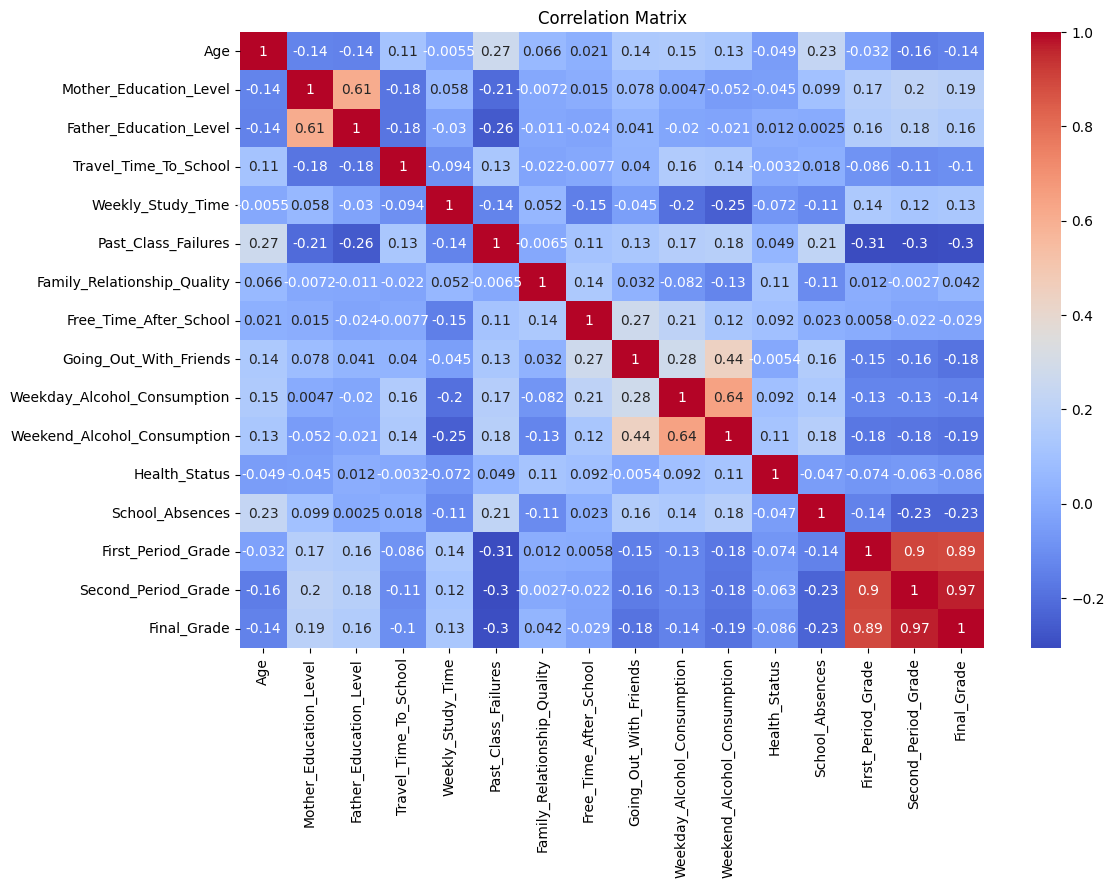

In [ ]:
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")

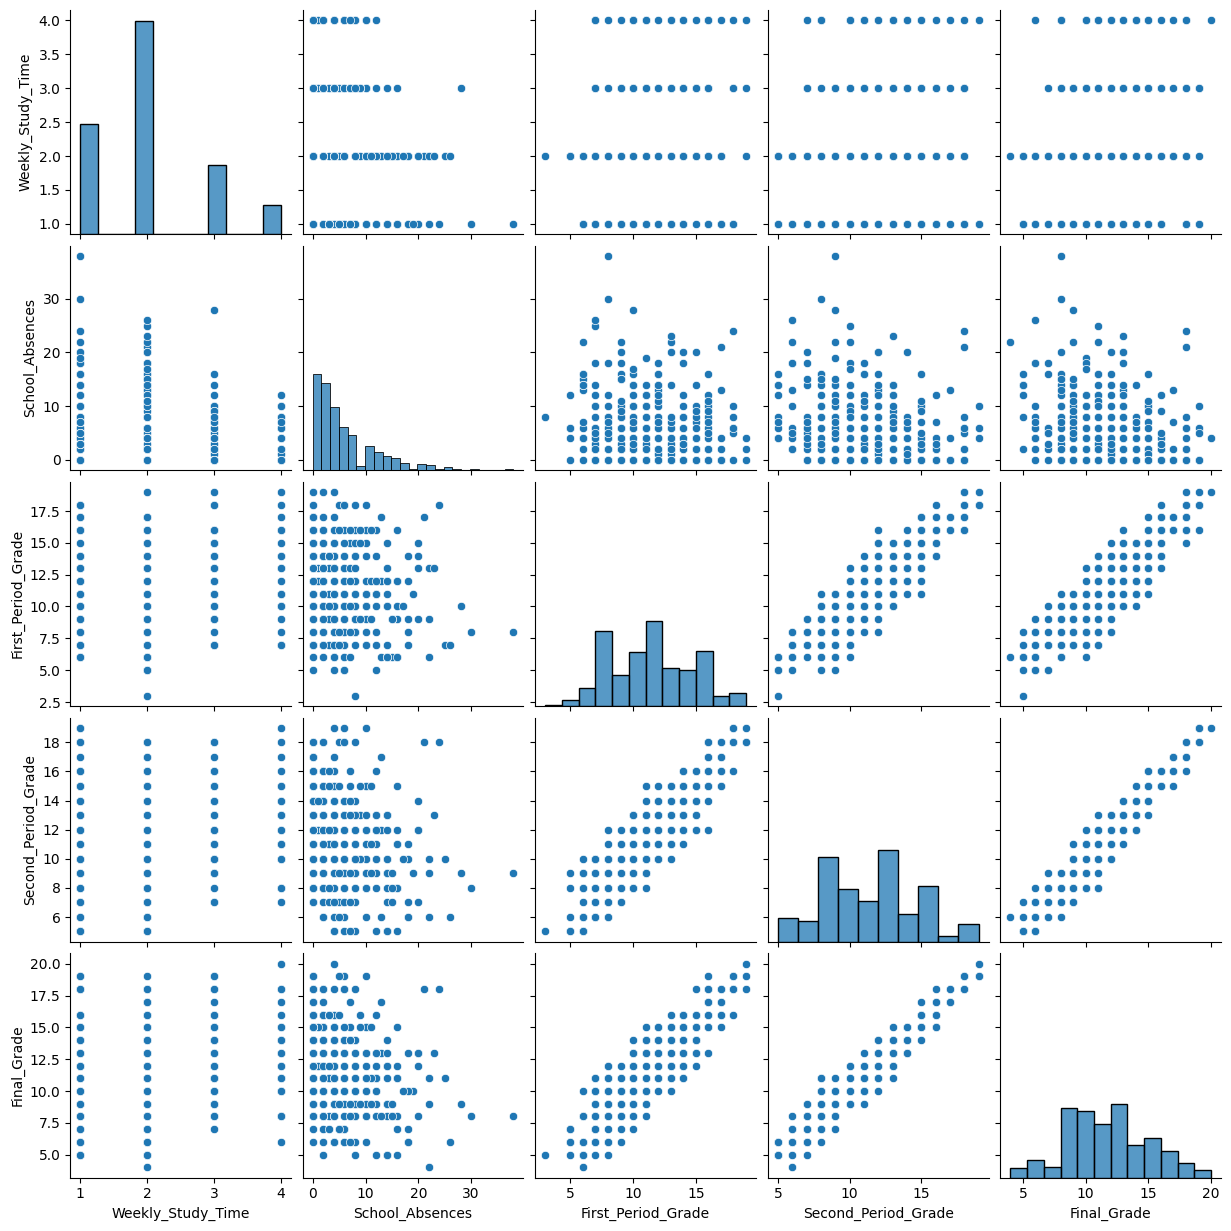

In [119]:
sns.pairplot(df[[
    "Weekly_Study_Time",
    "School_Absences",
    "First_Period_Grade",
    "Second_Period_Grade",
    "Final_Grade"
]])

# Insights

## Factors Effecting Final Grades

In [13]:
corr = df.corr(numeric_only=True)

corr["Final_Grade"].sort_values(ascending=False)

Final_Grade                    1.000000
Second_Period_Grade            0.904868
First_Period_Grade             0.801468
Mother_Education_Level         0.217147
Father_Education_Level         0.152457
Weekly_Study_Time              0.097820
Family_Relationship_Quality    0.051363
School_Absences                0.034247
Free_Time_After_School         0.011307
Weekend_Alcohol_Consumption   -0.051939
Weekday_Alcohol_Consumption   -0.054660
Health_Status                 -0.061335
Travel_Time_To_School         -0.117142
Going_Out_With_Friends        -0.132791
Age                           -0.161579
Past_Class_Failures           -0.360415
Name: Final_Grade, dtype: float64

**Insights**

Second_Period_Grade → strongest predictor

First_Period_Grade → strong predictor

Past_Class_Failures → highest negative influence

## Alcohol Consumption and Social Behavior

There is a relationship between going out and alcohol consumption:

|Variables|                                                  	Correlation|
|:---|:---|
|Going_Out_With_Friends ↔ Weekend_Alcohol_Consumption|       	0.44|
|Weekday_Alcohol_Consumption ↔ Weekend_Alcohol_Consumption|       0.64|

**Insight**

Students who socialize more frequently tend to consume more alcohol, especially on weekends.

However, the impact on grades appears moderate rather than strong.

## Study Time Has Weak Correlation with Grades

Surprisingly:

|Variable|	Correlation with Final Grade|
|:---|:---|
|Weekly_Study_Time|	0.13|

**Insight**

Study time alone does not strongly predict academic performance.

**Possible reasons:**

study quality matters more than study duration

some students study efficiently in less time

other factors (attendance, prior knowledge) play a bigger role

## Parents' Education Levels Are Related

|Variables|	Correlation|
|:---|:---|
|Mother_Education_Level ↔ Father_Education_Level|	0.61|

**Insight**

Parents' education levels tend to be similar within families, which is expected due to socio-economic patterns.

# Conclusion

The exploratory data analysis reveals that early academic performance is the strongest predictor of final grades. Factors such as past academic failures and school absences negatively influence performance. Social behaviors such as going out and alcohol consumption are correlated with each other but show only moderate relationships with academic outcomes. Interestingly, study time alone does not strongly predict grades, suggesting that study quality and other external factors may play a more important role.